# Classify spam vs no spam emails

In [67]:
import kagglehub
import pandas as pd
import os
from matplotlib import pyplot as plt
import seaborn as sn
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text  # Required to run exported models with TF Hub

## Import the dataset (dataset is taken from kaggle)

In [15]:
path = kagglehub.dataset_download("imgowthamg/email-spam-and-non-spam-datasets")

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("CSV files:", csv_files)

CSV files: ['mail_data.csv']


In [16]:
df = pd.read_csv(os.path.join(path, csv_files[0]))
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [19]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [20]:
tot = 4825 + 747

In [21]:
747 / tot

0.13406317300789664

In [22]:
4825/tot

0.8659368269921034

### 13.4% mail is spam and 86.59% non spam

In [33]:
df_spam = df[df['Category']=='spam']
df_spam.shape

(747, 2)

In [34]:
df_ham = df[df['Category']=='ham']
df_ham.shape

(4825, 2)

In [35]:
df_ham_downsampled = df_ham.sample(df_spam.shape[0])
df_ham_downsampled.shape

(747, 2)

In [36]:
df_balanced = pd.concat([df_ham_downsampled, df_spam])
df_balanced.shape

(1494, 2)

In [37]:
df_balanced['Category'].value_counts()

Category
ham     747
spam    747
Name: count, dtype: int64

In [38]:
df_balanced['spam']=df_balanced['Category'].apply(lambda x: 1 if x=='spam' else 0)
df_balanced.sample(5)

,Category,Message,spam
11,spam,"SIX chances to win CASH! From 100 to 20,000 po...",1
1072,spam,URGENT! We are trying to contact U. Todays dra...,1
2847,ham,Wat time u finish ur lect today?,0
1007,spam,Panasonic & BluetoothHdset FREE. Nokia FREE. M...,1
418,spam,FREE entry into our £250 weekly competition ju...,1


Split it into training and test data set

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_balanced['Message'],df_balanced['spam'], stratify=df_balanced['spam'])


In [40]:
X_train.head(4)

4436    Don't b floppy... b snappy & happy! Only gay c...
3074           Somebody should go to andros and steal ice
4735    Buy Space Invaders 4 a chance 2 win orig Arcad...
5147    Get your garden ready for summer with a FREE s...
Name: Message, dtype: str

## Now lets import BERT model and get embeding vectors for few sample statements

In [41]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

In [42]:
def get_sentence_embeding(sentences):
    preprocessed_text = bert_preprocess(sentences)
    return bert_encoder(preprocessed_text)['pooled_output']




In [43]:
get_sentence_embeding([
    "500$ discount. hurry up", 
    "Bhavin, are you up for a volleybal game tomorrow?"]
)

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.8435166 , -0.5132723 , -0.8884569 , ..., -0.7474881 ,
        -0.7531471 ,  0.9196447 ],
       [-0.87208354, -0.50544   , -0.94446695, ..., -0.8584753 ,
        -0.71745366,  0.8808297 ]], shape=(2, 768), dtype=float32)>

### Get embeding vectors for few sample words. Compare them using cosine similarity

In [44]:
e = get_sentence_embeding([
    "banana", 
    "grapes",
    "mango",
    "jeff bezos",
    "elon musk",
    "bill gates"
]
)

In [45]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([e[0]],[e[1]])


array([[0.9911088]], dtype=float32)

Values near to 1 means they are similar. 0 means they are very different. Above you can use comparing "banana" vs "grapes" you get 0.99 similarity as they both are fruits

In [73]:
cosine_similarity([e[0]],[e[3]])

array([[0.84703815]], dtype=float32)

Comparing banana with jeff bezos you still get 0.84 but it is not as close as 0.99 that we got with grapes

In [74]:
cosine_similarity([e[3]],[e[4]])

array([[0.98720336]], dtype=float32)

Jeff bezos and Elon musk are more similar then Jeff bezos and banana as indicated above

# Build Model

There are two types of models you can build in tensorflow.

(1) Sequential (2) Functional

So far we have built sequential model. But below we will build functional model. More information on these two is here: https://becominghuman.ai/sequential-vs-functional-model-in-keras-20684f766057

https://stackoverflow.com/questions/47605558/importerror-failed-to-import-pydot-you-must-install-pydot-and-graphviz-for-py

In [75]:
import tf_keras as keras

# Correct TF Hub URLs
bert_preprocess_url = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
bert_encoder_url = "https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4"

# Load BERT layers
bert_preprocess = hub.KerasLayer(bert_preprocess_url, name="bert_preprocess")
bert_encoder = hub.KerasLayer(bert_encoder_url, trainable=False, name="bert_encoder")

# Input layer
text_input = keras.layers.Input(shape=(), dtype=tf.string, name="text")

# BERT preprocessing and encoding
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

# Classification layers
pooled_output = outputs["pooled_output"]
dropout = keras.layers.Dropout(0.1, name="dropout")(pooled_output)
output = keras.layers.Dense(1, activation="sigmoid", name="output")(dropout)



In [76]:
# Final model
model = keras.Model(inputs=text_input, outputs=output)

model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 bert_preprocess (KerasLaye  {'input_type_ids': (None,    0         ['text[0][0]']                
 r)                          128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

In [77]:
sample_text = tf.constant(["This is a test email"])

preprocessed = bert_preprocess(sample_text)
bert_result = bert_encoder(preprocessed)

print(bert_result.keys())
print(bert_result["pooled_output"].shape)

dict_keys(['sequence_output', 'default', 'pooled_output', 'encoder_outputs'])
(1, 768)


In [53]:
len(X_train)

1120

In [55]:
import tf_keras as keras
METRICS = [
    keras.metrics.BinaryAccuracy(name="accuracy"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall")
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=METRICS
)


## Train the model

In [56]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
35/35 [==============================] - 119s 3s/step - loss: 1.0961 - accuracy: 0.5000 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2/10
35/35 [==============================] - 110s 3s/step - loss: 1.0453 - accuracy: 0.5000 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 3/10
35/35 [==============================] - 108s 3s/step - loss: 1.0071 - accuracy: 0.5000 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 4/10
35/35 [==============================] - 108s 3s/step - loss: 0.9652 - accuracy: 0.5000 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 5/10
35/35 [==============================] - 108s 3s/step - loss: 0.9153 - accuracy: 0.5000 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 6/10
35/35 [==============================] - 108s 3s/step - loss: 0.8843 - accuracy: 0.5000 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 7/10
35/35 [==============================] - 108s 3s/step - loss: 0.8550 - accuracy: 0.5000 - precision: 0.0000e+00 - recall: 0.0

In [57]:
model.evaluate(X_test, y_test)

12/12 [==============================] - 37s 3s/step - loss: 0.7604 - accuracy: 0.5000 - precision: 0.0000e+00 - recall: 0.0000e+00


[0.7604153752326965, 0.5, 0.0, 0.0]

In [58]:
y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()

12/12 [==============================] - 37s 3s/step


In [64]:
y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [65]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_predicted)
cm 

array([[187,   0],
       [187,   0]])

Text(50.83333333333333, 0.5, 'Truth')

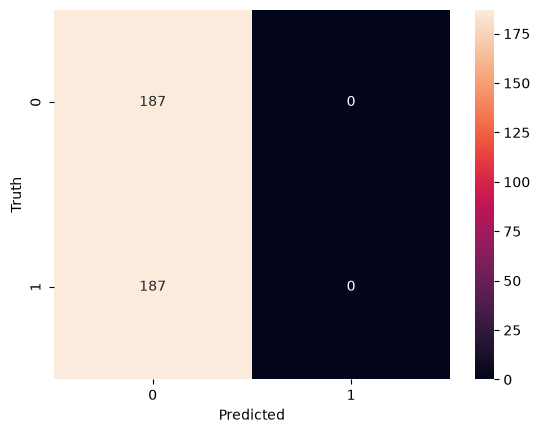

In [66]:
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')



In [62]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67       187
           1       0.00      0.00      0.00       187

    accuracy                           0.50       374
   macro avg       0.25      0.50      0.33       374
weighted avg       0.25      0.50      0.33       374



/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

### Inference

In [68]:
reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]


In [69]:
model.predict(reviews)

1/1 [==============================] - 0s 489ms/step


array([[0.32202867],
       [0.30499962],
       [0.32002696],
       [0.29838318],
       [0.29412568]], dtype=float32)